# Panel local projections IV: CPI on xi x oil

This notebook is a notebook-first version of the panel LP-IV workflow.

It mirrors `panel_local_projections.ipynb`, but estimates 2SLS local projections with:

- Endogenous shock: `xi_x_oil`
- Instrument: `xi_x_news`
- Outcome: quarterly CPI inflation (`cpi_pct_change`)


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [2]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"
news_column = "news_shock"  # "news_shock" or "surprise"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "exchange_rate",
#         "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
#         "value_column": "log_diff",
#         "merge_keys": ["country", "period"],
#         "merge_key_columns": {"country": "country_code", "period": "quarter"},
#         "status_column": None,
#     }
# ]
panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]

# Controls that actually enter the LP-IV regression.
regression_controls = ["exchange_rate", "output_gap", "policy_rate"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_year_fe = False
cov_type = "cluster_country"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
lag_xi_by_one_year_for_xi_x_oil = True

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)
print("news_path:", news_path)
print("news_column:", news_column)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
include_country_fe: True
include_year_fe: False
cov_type: cluster_country
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']
lag_xi_by_one_year_for_xi_x_oil: True
news_path: C:\Users\user\projects\academics\0_diss\analysis\data\processed\oil\kaenzig_oil_supply_surprises_quarterly.csv
news_column: news_shock


In [3]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column=news_column,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7522,80,1995,2022,23.625,1995-Q1,2022-Q4,94.025


In [4]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,news,xi_x_news,exchange_rate,output_gap,policy_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.002826,0.171750,-0.452902,-0.006742,0.147258,0.002102,NaN
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.000986,0.209522,0.865002,0.012877,0.131988,0.021675,NaN
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000171,0.179419,0.675704,0.010059,0.157769,0.062869,NaN
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.003251,0.234092,0.924390,0.018472,0.181845,-0.050575,NaN
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.003338,0.200532,-0.782905,-0.015644,0.131072,-0.056534,NaN


In [5]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7522


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,news,xi_x_news,exchange_rate,output_gap,policy_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.002826,0.171750,-0.452902,-0.006742,0.147258,0.002102,NaN
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.000986,0.209522,0.865002,0.012877,0.131988,0.021675,NaN
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000171,0.179419,0.675704,0.010059,0.157769,0.062869,NaN
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.003251,0.234092,0.924390,0.018472,0.181845,-0.050575,NaN
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.003338,0.200532,-0.782905,-0.015644,0.131072,-0.056534,NaN


In [6]:
irf_df, coef_df, models = lp.fit_panel_local_projections_iv(
    panel_df_model,
    y_col="cpi_pct_change",
    endog_col="xi_x_oil",
    instrument_col="xi_x_news",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.354924,0.084070,4.221772,0.000105,0.185979,0.523869,3528.0,50
1,1,xi_x_oil,0.419003,0.127616,3.283299,0.001897,0.162548,0.675457,3528.0,50
2,2,xi_x_oil,-0.158247,0.132521,-1.194125,0.238178,-0.424559,0.108065,3528.0,50
3,3,xi_x_oil,-0.049824,0.124575,-0.399951,0.690931,-0.300167,0.200519,3528.0,50
4,4,xi_x_oil,0.035332,0.072829,0.485141,0.629739,-0.111023,0.181688,3528.0,50
5,5,xi_x_oil,-0.157041,0.105719,-1.485451,0.143830,-0.369492,0.055410,3528.0,50
6,6,xi_x_oil,-0.085760,0.100536,-0.853025,0.397796,-0.287794,0.116275,3528.0,50
7,7,xi_x_oil,0.014323,0.075077,0.190779,0.849487,-0.136549,0.165196,3528.0,50
8,8,xi_x_oil,-0.078819,0.108422,-0.726960,0.470710,-0.296702,0.139064,3528.0,50
9,9,xi_x_oil,-0.152550,0.073831,-2.066198,0.044117,-0.300919,-0.004181,3528.0,50


In [7]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "xi_x_oil_lag1", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.053227,0.007774,6.846792,1.145843e-08,0.037604,0.068849,3528.0
1,0,xi_x_oil,0.354924,0.084070,4.221772,1.046405e-04,0.185979,0.523869,3528.0
2,0,xi_x_oil_lag1,0.357492,0.153848,2.323662,2.433534e-02,0.048322,0.666662,3528.0
69,1,const,0.051736,0.005590,9.254645,2.468828e-12,0.040502,0.062971,3528.0
70,1,xi_x_oil,0.419003,0.127616,3.283299,1.897159e-03,0.162548,0.675457,3528.0
71,1,xi_x_oil_lag1,-0.290078,0.156110,-1.858167,6.915838e-02,-0.603792,0.023636,3528.0
138,2,const,0.070478,0.008117,8.682460,1.761857e-11,0.054166,0.086791,3528.0
139,2,xi_x_oil,-0.158247,0.132521,-1.194125,2.381779e-01,-0.424559,0.108065,3528.0
140,2,xi_x_oil_lag1,0.022393,0.115002,0.194722,8.464160e-01,-0.208712,0.253498,3528.0
207,3,const,0.062930,0.008146,7.725284,5.037131e-10,0.046560,0.079300,3528.0


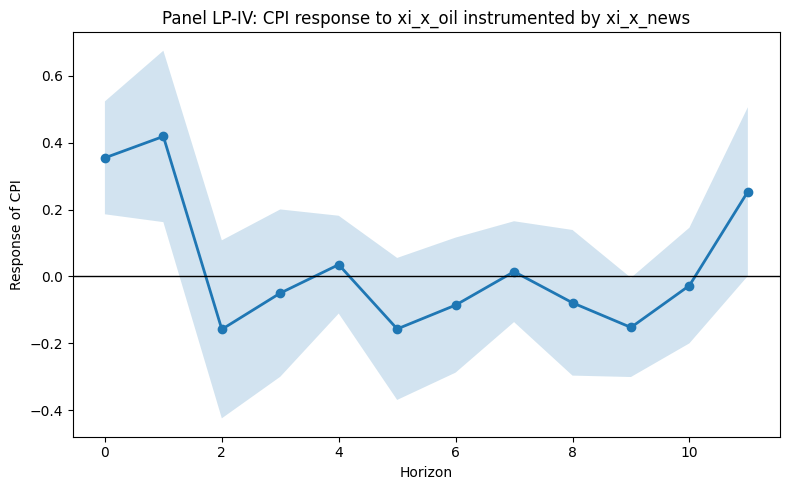

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, title="Panel LP-IV: CPI response to xi_x_oil instrumented by xi_x_news", ax=ax)
plt.tight_layout()
plt.show()


In [9]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                           IV2SLS Regression Results                            
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.531
Model:                           IV2SLS   Adj. R-squared:                  0.522
Method:                       Two Stage   F-statistic:                     108.6
                          Least Squares   Prob (F-statistic):               0.00
Date:                  Mon, 30 Mar 2026                                         
Time:                          00:43:39                                         
No. Observations:                  3528                                         
Df Residuals:                      3459                                         
Df Model:                            68                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 68, but rank is 19
  warnings.warn('covariance of constraints does not have full '
